In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [10]:
veri = pd.read_csv("C:/Users/kerem/Desktop/Akıllı Trafik/Modeller/proje.csv")
veri = veri.copy()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda  x: '%.3f' % x)
pd.set_option('display.width', 1000)
warnings.filterwarnings('ignore')

Eğitim ve test verisi ayrımı (zaman bazlı)

In [11]:
veri['rain_encoded'] = veri['rainfall_condition'].astype('category').cat.codes
def time_split_grouped(veri, group='GEOHASH_SHORT', ratio=0.8):
    train_list, test_list = [], []
    for g, sub in veri.groupby(group):
        sub = sub.sort_values(["DATE", "TIME_PERIOD"])  # her GEOHASH için zaman sırası
        split_idx = int(len(sub) * ratio)
        train_list.append(sub.iloc[:split_idx])
        test_list.append(sub.iloc[split_idx:])
    return pd.concat(train_list), pd.concat(test_list)

In [12]:
# Time-period sırası + tarih + geohash sırası
veri = veri.sort_values(["GEOHASH_SHORT", "DATE", "TIME_PERIOD_NUM"]).reset_index(drop=True)

# Gruplara göre zaman temelli ayırma
train, test = time_split_grouped(veri, group="GEOHASH_SHORT", ratio=0.8)

print("Train:", train.shape)
print("Test :", test.shape)

Train: (216718, 30)
Test : (54288, 30)


Özellik önemi

In [13]:
def plot_feature_importance(model, X_train, model_name):

    importance = model.feature_importances_
    features = X_train.columns

    indices = importance.argsort()[-20:]
    plt.rcParams.update({'font.size': 5})

    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importance[indices], align="center")
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel("Özellik Önemi")
    plt.title(model_name)
    plt.show()

Feature Seçimi

In [14]:
features = ['MINIMUM_SPEED', 'MAXIMUM_SPEED', 'AVERAGE_SPEED',
             'NUMBER_OF_VEHICLES', 'rain_encoded', 'haftanin_gunu', 'ay', 'gun_no']

X_train = train[features]
y_train = train['DENSITY']
X_test = test[features]
y_test = test['DENSITY']

important_feats = [c for c in veri.columns if 'lag' in c or 'roll' in c] + features # features daha sonra tanımlı
# örn:
veri = veri.sort_values(["GEOHASH_SHORT", "DATE", "TIME_PERIOD_NUM"])
# eğer çok veri kaybı yaşamıyorsan:
veri = veri.dropna(subset=important_feats + ['DENSITY'])

In [15]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    return preds, {'mae':mae, 'rmse':rmse, 'r2':r2}

--- 10) RandomForest (temel eğitim) ---

--- RandomForest ---
MAE: 14.5726 | RMSE: 69.5167 | R2: 0.9240


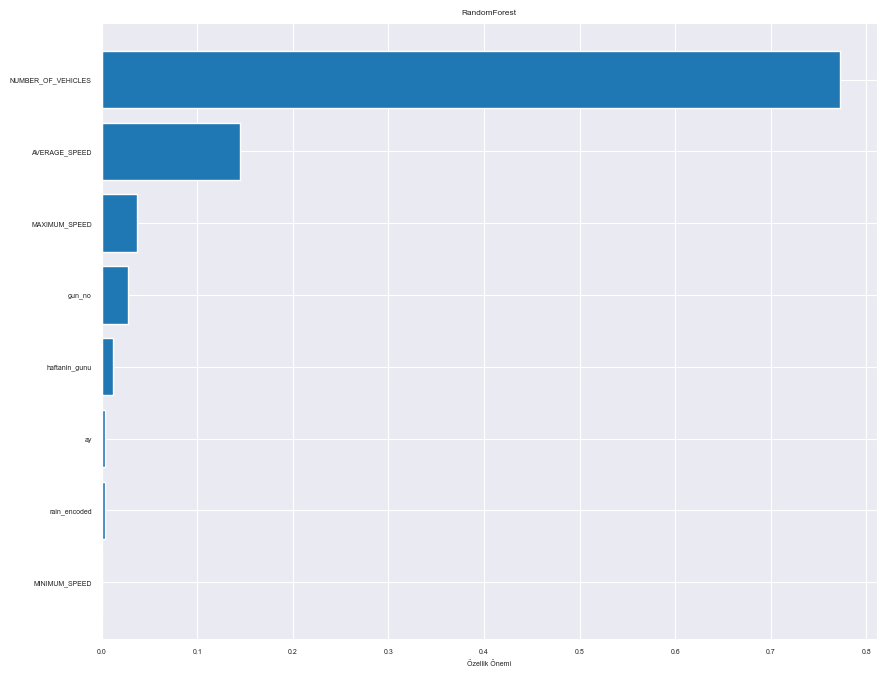

In [16]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds, rf_metrics = evaluate_model(rf, X_test, y_test, "RandomForest")
plot_feature_importance(rf, X_train, model_name="RandomForest")

--- 11) LightGBM (temel eğitim) ---

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 824
[LightGBM] [Info] Number of data points in the train set: 216718, number of used features: 8
[LightGBM] [Info] Start training from score 141.383157
--- LightGBM ---
MAE: 15.4739 | RMSE: 66.0916 | R2: 0.9313


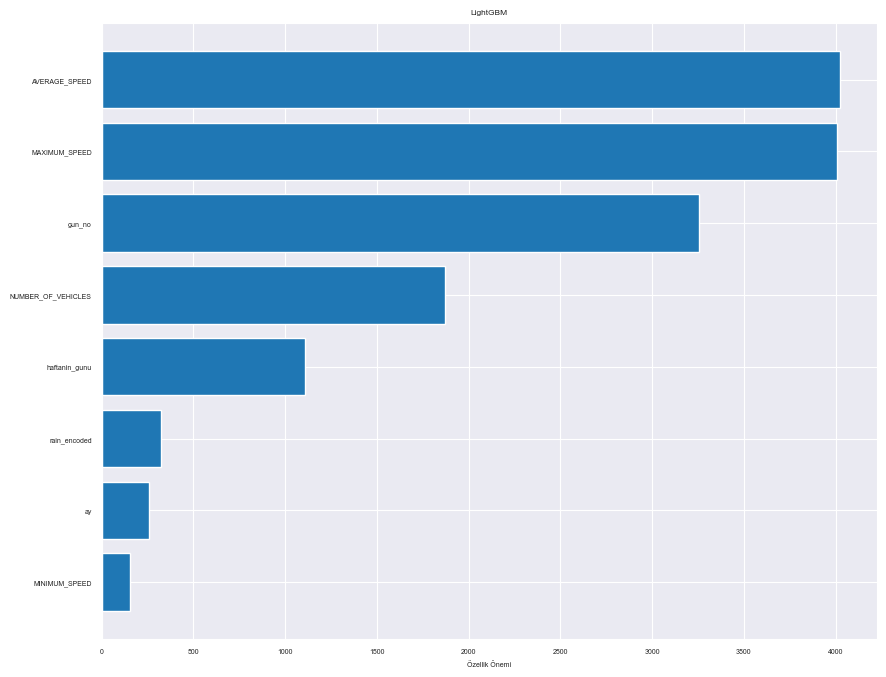

In [17]:
lgbm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse'
)
lgbm_preds, lgbm_metrics = evaluate_model(lgbm, X_test, y_test, "LightGBM")
plot_feature_importance(lgbm, X_train, model_name="LightGBM")

--- 12) XGBoost (temel eğitim) ---

--- XGBoost ---
MAE: 18.5260 | RMSE: 74.3722 | R2: 0.9130


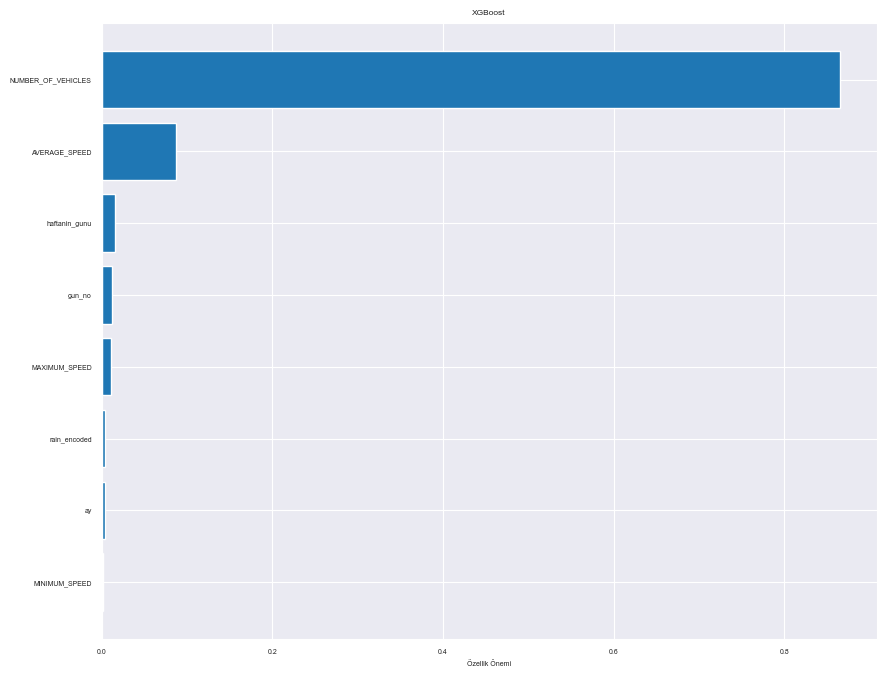

In [18]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror',
    eval_metric='rmse'
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_preds, xgb_metrics = evaluate_model(xgb, X_test, y_test, "XGBoost")
plot_feature_importance(xgb, X_train, model_name="XGBoost")

--- 13) Karşılaştırma tablosu ---

In [19]:
results = pd.DataFrame({
    'model': ['RandomForest','LightGBM','XGBoost'],
    'mae': [rf_metrics['mae'], lgbm_metrics['mae'], xgb_metrics['mae']],
    'rmse':[rf_metrics['rmse'], lgbm_metrics['rmse'], xgb_metrics['rmse']],
    'r2':[rf_metrics['r2'], lgbm_metrics['r2'], xgb_metrics['r2']]
})
print("\nModel karşılaştırması:")
print(results.sort_values('rmse'))


Model karşılaştırması:
          model    mae   rmse    r2
1      LightGBM 15.474 66.092 0.931
0  RandomForest 14.573 69.517 0.924
2       XGBoost 18.526 74.372 0.913
